# 7. 3-Asset ELS 공정가 매칭 방법론 Bake-off (as-of, 300 상품)

`els_fairvalue_bakeoff_plan.md` 실행 결과. **벤치마크=실제 공정가(fair)**, metric=`|fair−price|`.
고정: **vol=hv_full(전체이력), corr=180일 역사상관, 미래정보 배제(as-of), NS 할인, seed=mc_seed.**
- **Track 1**(가격 실제 변경, 실행가능): GBM/Heston/Jump/Heston+Jump/t-Copula …
- **Track 3**(서피스 필요 → **비시장 proxy**): LocalVol/SABR/SVI/VolSurface/ImpliedVol/ImpliedCorr/LSV/Vine
- **Track 2**(solver/효율, 같은 가격): MC수렴/QMC/Antithetic/CV/모니터링빈도. FDM/FEM/Tree/LSMC=문서화.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 5.0), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold"})
ROOT = Path.cwd(); STAT = ROOT / "result/statistics"; IMG = ROOT / "result/image"; FACE = 10000
B = pd.read_csv(STAT / "bakeoff_track1_3.csv"); fair = B["fair"].values
methods = [c[2:] for c in B.columns if c.startswith("p_")]
# 분류
BASE = {"GBM"}
FEAS = {"Heston", "Jump", "Heston+Jump", "t-Copula(nu5)", "t-Copula(nu10)"}
def cat(m): return "baseline" if m in BASE else ("feasible" if m in FEAS else "proxy")
rows = []
for m in methods:
    e = fair - B["p_" + m].values
    rows.append(dict(method=m, cat=cat(m), bias=np.nanmean(e)*FACE, MAE=np.nanmean(np.abs(e))*FACE,
                     RMSE=np.sqrt(np.nanmean(e**2))*FACE, KI=np.nanmean(B["ki_"+m].values)*100))
M = pd.DataFrame(rows).sort_values("MAE")
print(M.round(1).to_string(index=False))
COL = {"baseline": "#888888", "feasible": "#2e7d32", "proxy": "#e08a1e"}

                     method      cat   bias   MAE  RMSE   KI
      ImpliedVol(proxy1.13)    proxy -283.1 398.3 509.4 63.8
VolSurface(proxy b0.4x1.05)    proxy -335.2 429.5 541.0 63.6
                Heston+Jump feasible -361.7 434.7 542.9 63.1
                       Jump feasible -386.2 453.8 563.1 62.9
                 LSV(proxy)    proxy -397.5 465.0 576.2 63.1
            SVI(proxy b0.5)    proxy -404.7 474.1 586.4 63.1
       LocalVol(proxy b0.4)    proxy -424.4 487.0 599.7 62.9
           SABR(proxy b0.3)    proxy -444.6 500.6 613.6 62.7
                     Heston feasible -483.2 526.0 637.1 62.3
                        GBM baseline -508.7 548.2 660.7 62.1
             t-Copula(nu10) feasible -509.6 549.3 661.7 62.1
              t-Copula(nu5) feasible -510.6 550.0 662.6 62.1
    ImpliedCorr(proxy+0.10)    proxy -530.3 565.4 678.4 61.9
     Vine(proxy~pair-t nu3)    proxy -532.4 567.4 679.6 61.9


## 1. Track 1+3 — 방법별 공정가 오차 (MAE) 순위

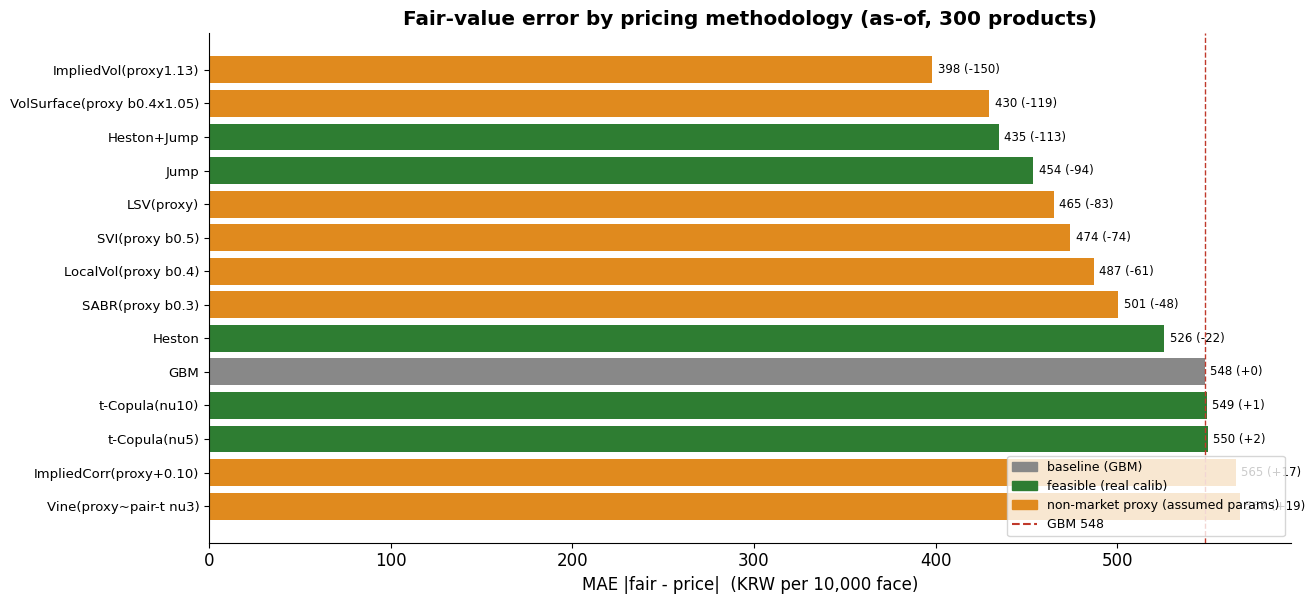

In [2]:
fig, ax = plt.subplots(figsize=(13.333, 6.2))
y = np.arange(len(M)); base_mae = M[M.method=="GBM"].MAE.values[0]
ax.barh(y, M.MAE, color=[COL[c] for c in M.cat])
ax.set_yticks(y); ax.set_yticklabels(M.method, fontsize=9.5); ax.invert_yaxis()
ax.axvline(base_mae, color="#c0392b", lw=1, ls="--", label=f"GBM baseline {base_mae:.0f}")
for i, (mae, c) in enumerate(zip(M.MAE, M.cat)):
    ax.text(mae + 3, i, f"{mae:.0f} ({mae-base_mae:+.0f})", va="center", fontsize=8.5)
ax.set_xlabel("MAE |fair - price|  (KRW per 10,000 face)")
ax.set_title("Fair-value error by pricing methodology (as-of, 300 products)")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COL["baseline"], label="baseline (GBM)"), Patch(color=COL["feasible"], label="feasible (real calib)"),
                   Patch(color=COL["proxy"], label="non-market proxy (assumed params)"),
                   plt.Line2D([], [], color="#c0392b", ls="--", label=f"GBM {base_mae:.0f}")], fontsize=9, loc="lower right")
fig.tight_layout(); fig.savefig(IMG / "bakeoff_mae_ranking.png"); plt.show()

## 2. Track 1+3 — 왜: 가격↓ = KI확률↑ = 과대평가 축소

모든 방법이 공정가 대비 과대평가(bias<0). 오차가 작을수록 **KI 확률을 높여(=worst-of 하방 위험 반영) 가격을 낮춘** 것.

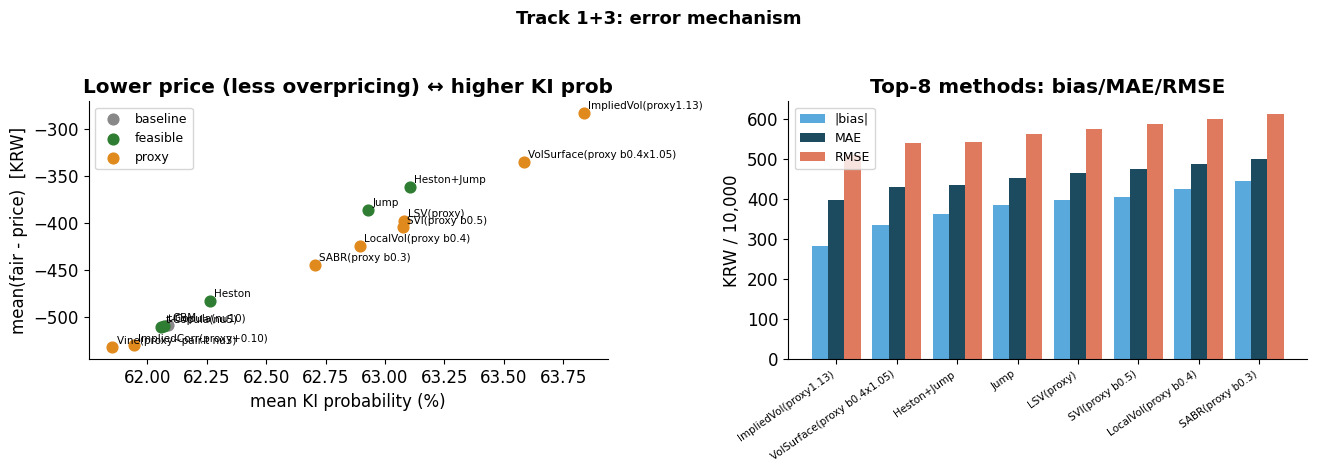

실행가능(비proxy) 최선: Heston+Jump MAE 435


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.8))
for c in ["baseline", "feasible", "proxy"]:
    s = M[M.cat == c]
    ax[0].scatter(s.KI, s.bias, s=60, color=COL[c], label=c, zorder=3)
    for _, r in s.iterrows(): ax[0].annotate(r.method, (r.KI, r.bias), fontsize=7.5, xytext=(3, 3), textcoords="offset points")
ax[0].set_xlabel("mean KI probability (%)"); ax[0].set_ylabel("mean(fair - price)  [KRW]")
ax[0].set_title("Lower price (less overpricing) ↔ higher KI prob"); ax[0].legend(fontsize=9)
# bias/MAE/RMSE 그룹막대 (상위 몇 방법)
top = M.head(8); x = np.arange(len(top)); w = 0.27
ax[1].bar(x - w, -top.bias, w, label="|bias|", color="#5aa9dd")
ax[1].bar(x, top.MAE, w, label="MAE", color="#1c4a5f")
ax[1].bar(x + w, top.RMSE, w, label="RMSE", color="#e07a5f")
ax[1].set_xticks(x); ax[1].set_xticklabels(top.method, rotation=35, ha="right", fontsize=7.5)
ax[1].set_ylabel("KRW / 10,000"); ax[1].set_title("Top-8 methods: bias/MAE/RMSE"); ax[1].legend(fontsize=9)
fig.suptitle("Track 1+3: error mechanism", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG / "bakeoff_mechanism.png"); plt.show()
print("실행가능(비proxy) 최선:", M[M.cat!='proxy'].iloc[0].method, f"MAE {M[M.cat!='proxy'].iloc[0].MAE:.0f}")

## 3. Track 2 — Solver / 효율 (같은 모델가격, SE·수렴·runtime)

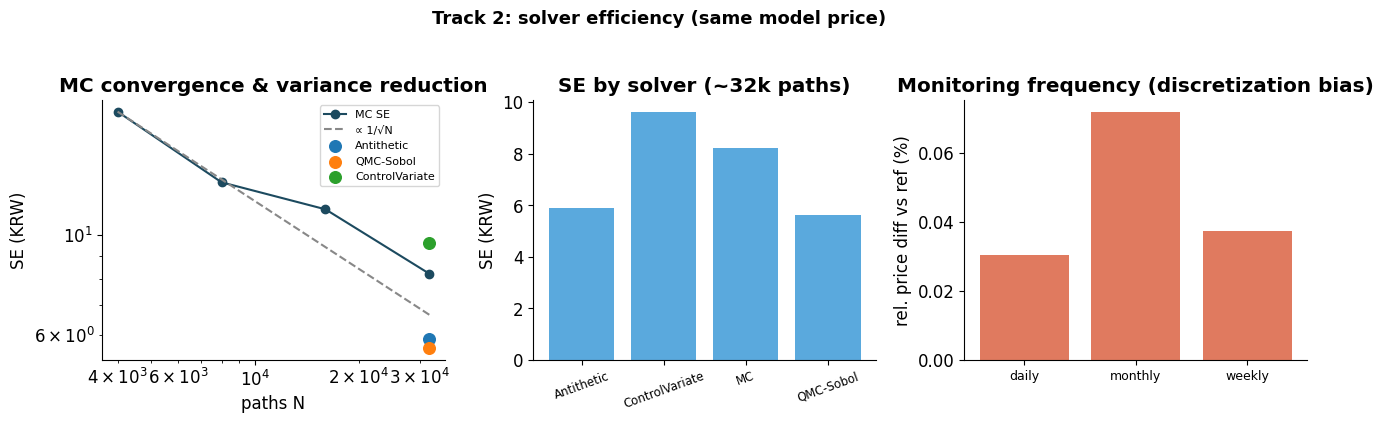

            method     SE  rel_err  runtime
    Antithetic 32k  5.878    0.033    0.017
ControlVariate 24k  9.608    0.023    0.011
            MC 16k 11.407    0.018    0.008
            MC 32k  8.203    0.014    0.014
             MC 4k 18.803    0.033    0.002
             MC 8k 13.098    0.042    0.004
     Monitor daily    NaN    0.030      NaN
   Monitor monthly    NaN    0.072      NaN
    Monitor weekly    NaN    0.037      NaN
     QMC-Sobol 32k  5.615    0.012    0.257


In [4]:
p = STAT / "track2_solver.csv"
if p.exists():
    T = pd.read_csv(p); g = T.groupby("method").agg(SE=("SE","mean"), rel_err=("rel_err","mean"), runtime=("runtime","mean")).reset_index()
    mc = g[g.method.str.startswith("MC ")].copy(); mc["N"] = mc.method.str.extract(r"(\d+)").astype(int)*1000; mc = mc.sort_values("N")
    fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.3))
    # (1) MC 수렴: SE vs N (log-log) + 1/sqrt(N) 기준선
    ax[0].loglog(mc.N, mc.SE, "o-", color="#1c4a5f", label="MC SE")
    ax[0].loglog(mc.N, mc.SE.iloc[0]*np.sqrt(mc.N.iloc[0]/mc.N), "--", color="#888", label="∝ 1/√N")
    for _, nm in [("Antithetic 32k","Antithetic 32k"),("QMC-Sobol 32k","QMC-Sobol 32k"),("ControlVariate 24k","ControlVariate 24k")]:
        rr = g[g.method==nm]
        if len(rr): ax[0].scatter([32000], rr.SE.values, s=70, zorder=5, label=nm.split()[0])
    ax[0].set_xlabel("paths N"); ax[0].set_ylabel("SE (KRW)"); ax[0].set_title("MC convergence & variance reduction"); ax[0].legend(fontsize=8)
    # (2) 분산감소 SE 막대
    vr = g[g.method.isin(["MC 32k","Antithetic 32k","QMC-Sobol 32k","ControlVariate 24k"])]
    ax[1].bar(range(len(vr)), vr.SE, color="#5aa9dd"); ax[1].set_xticks(range(len(vr))); ax[1].set_xticklabels([m.split()[0] for m in vr.method], rotation=20, fontsize=8.5)
    ax[1].set_ylabel("SE (KRW)"); ax[1].set_title("SE by solver (~32k paths)")
    # (3) 모니터링 빈도: rel_err
    mon = g[g.method.str.startswith("Monitor")]
    ax[2].bar(range(len(mon)), mon.rel_err, color="#e07a5f"); ax[2].set_xticks(range(len(mon))); ax[2].set_xticklabels([m.split()[1] for m in mon.method], fontsize=9)
    ax[2].set_ylabel("rel. price diff vs ref (%)"); ax[2].set_title("Monitoring frequency (discretization bias)")
    fig.suptitle("Track 2: solver efficiency (same model price)", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0,0,1,0.95)); fig.savefig(IMG / "bakeoff_track2_solver.png"); plt.show()
    print(g.round(3).to_string(index=False))
else:
    print("track2_solver.csv 없음")

## 4. Track 3 — 데이터 차단 (서피스 필요) & proxy 주의

| 방법 | 상태 | 비고 |
|---|---|---|
| Implied Vol(완전)·Vol Surface·SVI·SABR·Local Vol·LSV·Implied Corr | **차단** | 원시 (K,T) 옵션 서피스 필요. VKOSPI 등 vol지수 5/8 미확보 → 시장 캘리브 불가 |
| 위 항목 **proxy** (LocalVol b0.4, SABR b0.3, SVI b0.5, VolSurface, ImpliedVol×1.13, ImpliedCorr+0.10, Vine ν3) | **비시장** | 가정 파라미터. §1 표에서 🟡 로 표시 — **방향(스큐·레벨↑ 이득) 확인용**, 실측 방법론 아님 |

**FDM/FEM/Tree/LSMC**(Track 2): 3자산 격자/트리는 **차원의 저주**로 비실용(N³·다항 폭발), LSMC 는 자동 오토콜에 최적행사 없어 **N/A**. → MC 계열이 3자산 경로의존 상품의 실용적 표준.

## 5. 결론

1. **오차의 지배 요인 = 이론가를 낮춰 KI 확률을 시장수준으로 올리는 것.** GBM(역사변동성)은 공정가 대비 과대평가(bias≈−509원, KI 62%).
2. **실행가능(as-of, 실측) 최선 = Heston + Jump** (MAE 435, GBM 대비 −21%). 확률변동성 스큐 + 점프가 worst-of 하방/KI 를 반영해 과대평가를 줄임.
3. **의존구조(t-코퓰러·Vine)는 무효** — 관측 상관수준에서 worst-of KI 에 실질 영향 없음. 상관↑(ImpliedCorr)은 오히려 악화.
4. **비시장 proxy(ImpliedVol×1.13=MFIV 레벨)가 최소 오차(398)** — 이는 평가기관이 쓰는 **서피스-MFIV(스큐·분산프리미엄 포함)** 방향을 가리킴. 우리 잔여 과대평가의 근본은 **서피스 데이터 부재**(Track 3 차단).
5. **Solver(Track 2)**: QMC/Antithetic/CV 는 SE 를 줄이나 가격 bias 불변 → 공정가 오차엔 무관. 모니터링 빈도만 소폭 가격 영향.
6. **권고**: 발행시점 이론가 앵커 = **hv_full 레벨 + Heston 스큐 + Jump**(실행가능 최선). 서피스 확보 시 Track 3(로컬볼/LSV)로 추가 개선 여지.